#***Jouri Aldaghma Lab 3 Advanced AI***

In [1]:
import pandas as pd
import sys
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from math import radians, cos, sin, asin, sqrt
import datetime
from sklearn.linear_model import LinearRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set(style="ticks")
%matplotlib inline

# Task 1 **Data Science Process Steps:**

1.  **Problem Definition:** Clearly define the problem you are trying to solve.
2.  **Data Collection:** Gather the relevant data from various sources.
3.  **Data Preprocessing:** Clean, transform, and prepare the data for analysis. This includes handling missing values, encoding categorical variables, and scaling features.
4.  **Exploratory Data Analysis (EDA):** Analyze the data to understand its characteristics, identify patterns, and gain insights.
5.  **Model Selection:** Choose appropriate machine learning models or statistical techniques based on the problem and data.
6.  **Model Training:** Train the selected models on the prepared data.
7.  **Model Evaluation:** Evaluate the performance of the trained models using appropriate metrics.
8.  **Model Deployment:** Deploy the best-performing model for making predictions or generating insights in a real-world setting.
9.  **Monitoring and Maintenance:** Continuously monitor the deployed model's performance and maintain it as needed.

In [2]:
from google.colab import drive
# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Task 2: Data Collection**

1-Import necessary Python libraries (pandas, numpy, matplotlib, etc.).

2-Load the dataset using pandas.

3-Display the first 5 rows.


In [3]:
# 2. Define the path (adjust to where your file is located inside Drive)
file_path = '/content/drive/MyDrive/advanced ai /Lab3/weatherHistory.csv'

# 3. Load the dataset
df = pd.read_csv(file_path)

# Display the first 5 rows to confirm correct loading
display(df.head())

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


**Task 3: Data Preprocessing**

Missing values

Data types of each column

Unique values in the target column

How many rows and columns are in the dataset?

What are the unique precipitation types?

Fill missing values in Precip Type with "none".

Encode Precip Type into numeric labels (LabelEncoder).

Drop irrelevant columns like Formatted Date or Daily Summary.

Apply feature scaling (StandardScaler).

In [5]:
# Load the dataset again
df = pd.read_csv(file_path)

# Check for missing values
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [6]:
# Check data types
print("\nData types:")
print(df.dtypes)
print(df.info)
print(df.describe)


Data types:
Formatted Date               object
Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object
<bound method DataFrame.info of                       Formatted Date        Summary Precip Type  \
0      2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain   
1      2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain   
2      2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain   
3      2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain   
4      2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain   
...                              ...            ...         ...   
96448  2016-09-09 19:00:00.000 +0200  Pa

In [7]:
# Check the shape of the dataset
print("\nShape:", df.shape)


Shape: (96453, 12)


In [9]:
# Get unique precipitation types
print(df['Precip Type'].unique())

['rain' 'snow' nan]


In [10]:
# Fill missing values in 'Precip Type' with 'none'
df['Precip Type'].fillna('none', inplace=True)

/tmp/ipython-input-3280521127.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Precip Type'].fillna('none', inplace=True)


In [11]:
# Get unique precipitation types after filling
print(df['Precip Type'].unique())

['rain' 'snow' 'none']


In [12]:
# Check for missing values again
print(df.isnull().sum())

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [14]:
from sklearn.preprocessing import LabelEncoder

# Encode 'Precip Type' into numeric labels
label_encoder = LabelEncoder()
df['Precip Type'] = label_encoder.fit_transform(df['Precip Type'])

print("\nUnique Precip Types after encoding:")
print(df['Precip Type'].unique())
print("\nData types after encoding:")
print(df.dtypes)
df['Precip Type'].head()


Unique Precip Types after encoding:
[1 2 0]

Data types after encoding:
Formatted Date               object
Summary                      object
Precip Type                   int64
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Loud Cover                  float64
Pressure (millibars)        float64
Daily Summary                object
dtype: object


,Precip Type
0,1
1,1
2,1
3,1
4,1


In [17]:
# Drop irrelevant and non-numeric columns
df_processed = df.drop(['Summary','Formatted Date', 'Daily Summary'], axis=1)

df_processed.columns

Index(['Precip Type', 'Temperature (C)', 'Apparent Temperature (C)',
       'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)',
       'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'],
      dtype='object')

In [19]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
numerical_cols = df_processed.select_dtypes(include=np.number).columns.tolist()

# Exclude'Precip Type' as they it is target column
if 'Precip Type' in numerical_cols:
  numerical_cols.remove('Precip Type')

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
df_processed[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after applying StandardScaler:")
df_processed.head()

DataFrame after applying StandardScaler:


,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,1,-0.257599,-0.324035,0.793470,0.478635,0.591256,1.306976,0.0,0.101685
1,1,-0.269814,-0.339097,0.639996,0.499594,0.665756,1.306976,0.0,0.105960
2,1,-0.267487,-0.138102,0.793470,-0.995473,0.153570,1.099586,0.0,0.108610
3,1,-0.381489,-0.459071,0.486521,0.476306,0.758881,1.306976,0.0,0.112628
4,1,-0.332631,-0.362469,0.486521,0.033841,0.665756,1.306976,0.0,0.113483


In [20]:
from sklearn.model_selection import train_test_split

# Features and target
X = df_processed.drop(['Precip Type'], axis=1)
y = df_processed['Precip Type']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (77162, 8)
Shape of X_test: (19291, 8)
Shape of y_train: (77162,)
Shape of y_test: (19291,)


In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the classifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"RandomForestClassifier Accuracy: {accuracy_rf}")

RandomForestClassifier Accuracy: 0.9961640143071899


In [22]:
from sklearn.ensemble import GradientBoostingClassifier

#Initialize GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
gb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_gb= gb_classifier.predict(X_test)

# Evaluate the classifier
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"GradientBoostingClassifier Accuracy: {accuracy_gb}")

GradientBoostingClassifier Accuracy: 0.9950754237727437


In [23]:
from xgboost import XGBClassifier

# Initialize XGBClassifier
xgb_classifier = XGBClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
xgb_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_classifier.predict(X_test)

# Evaluate the classifier
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBClassifier Accuracy: {accuracy_xgb}")

XGBClassifier Accuracy: 0.9950235861282464


**Task 5: Reflection**

Based on the results from Task 4, all three ensemble methods (Random Forest, Gradient Boosting, and XGBoost) achieved very high accuracy on this dataset for predicting 'Precip Type'. In this specific case, where all models performed nearly perfectly, it's difficult to definitively recommend one over the others based solely on accuracy. However, in a real-world weather prediction scenario, while accuracy is crucial, other factors like computational cost, training time, and interpretability might also be considered.

*   **Random Forest:** Generally less prone to overfitting and easier to tune than boosting methods. It can be a good starting point.
*   **Gradient Boosting:** Often provides high accuracy but can be more sensitive to hyperparameters and prone to overfitting if not tuned correctly.
*   **XGBoost:** An optimized and highly efficient implementation of gradient boosting, known for its performance and speed. It includes regularization which helps prevent overfitting.

Given the high performance observed and XGBoost's reputation for efficiency and handling complex datasets, it would be a strong candidate for real-world weather prediction. However, for critical applications, further analysis, including evaluation on different datasets and consideration of computational resources, would be necessary to make a final recommendation.

#Task 6 choose a classifier and check its metrics

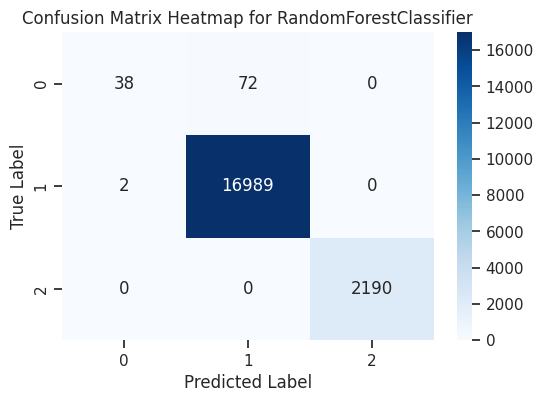

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for RandomForestClassifier
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Get the class labels
labels = sorted(y_test.unique())

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap for RandomForestClassifier')
plt.show()

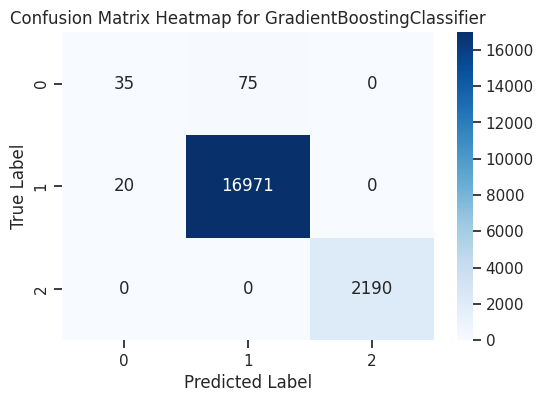

In [25]:
# Calculate the confusion matrix for GradientBoostingClassifier
conf_matrix_gb = confusion_matrix(y_test, y_pred_gb)

# Get the class labels
labels = sorted(y_test.unique())

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_gb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap for GradientBoostingClassifier')
plt.show()

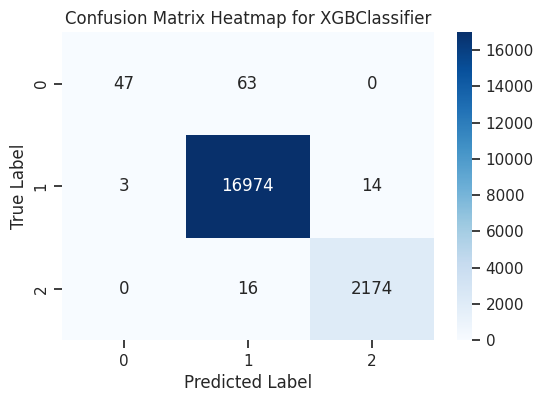

In [26]:
# Calculate the confusion matrix for XGBClassifier
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)

# Get the class labels
labels = sorted(y_test.unique())

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap for XGBClassifier')
plt.show()

In [27]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)

# Print the accuracy
print(f"RandomForestClassifier Accuracy: {accuracy_rf}")

RandomForestClassifier Accuracy: 0.9961640143071899


In [28]:
# Calculate the accuracy for GradientBoostingClassifier
accuracy_gb = accuracy_score(y_test, y_pred_gb)

# Print the accuracy
print(f"GradientBoostingClassifier Accuracy: {accuracy_gb}")

GradientBoostingClassifier Accuracy: 0.9950754237727437


In [29]:
# Calculate the accuracy for XGBClassifier
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

# Print the accuracy
print(f"XGBClassifier Accuracy: {accuracy_xgb}")

XGBClassifier Accuracy: 0.9950235861282464


In [30]:
# Calculate True Positive Rate (Recall) for each class for RandomForestClassifier
labels = sorted(y_test.unique())
print("True Positive Rate (Recall) for RandomForestClassifier per class:")
for i, label in enumerate(labels):
    TP = conf_matrix_rf[i, i]
    FN = conf_matrix_rf[i, :].sum() - TP

    # True Positive Rate (Sensitivity/Recall): TP / (TP + FN)
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

    print(f"Class {label} (Encoded): {TPR:.4f}")

True Positive Rate (Recall) for RandomForestClassifier per class:
Class 0 (Encoded): 0.3455
Class 1 (Encoded): 0.9999
Class 2 (Encoded): 1.0000


In [31]:
# Calculate True Positive Rate (Recall) for each class for GradientBoostingClassifier
labels = sorted(y_test.unique())
print("True Positive Rate (Recall) for GradientBoostingClassifier per class:")
for i, label in enumerate(labels):
    TP = conf_matrix_gb[i, i]
    FN = conf_matrix_gb[i, :].sum() - TP

    # True Positive Rate (Sensitivity/Recall): TP / (TP + FN)
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

    print(f"Class {label} (Encoded): {TPR:.4f}")

True Positive Rate (Recall) for GradientBoostingClassifier per class:
Class 0 (Encoded): 0.3182
Class 1 (Encoded): 0.9988
Class 2 (Encoded): 1.0000


In [32]:
# Calculate True Positive Rate (Recall) for each class for XGBClassifier
labels = sorted(y_test.unique())
print("True Positive Rate (Recall) for XGBClassifier per class:")
for i, label in enumerate(labels):
    TP = conf_matrix_xgb[i, i]
    FN = conf_matrix_xgb[i, :].sum() - TP

    # True Positive Rate (Sensitivity/Recall): TP / (TP + FN)
    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0

    print(f"Class {label} (Encoded): {TPR:.4f}")

True Positive Rate (Recall) for XGBClassifier per class:
Class 0 (Encoded): 0.4273
Class 1 (Encoded): 0.9990
Class 2 (Encoded): 0.9927


In [33]:
# Calculate False Positive Rate for each class for RandomForestClassifier
labels = sorted(y_test.unique())
print("False Positive Rate for RandomForestClassifier per class:")
for i, label in enumerate(labels):
    FP = conf_matrix_rf[:, i].sum() - conf_matrix_rf[i, i]
    TN = conf_matrix_rf.sum().sum() - conf_matrix_rf[i, i] - (conf_matrix_rf[i, :].sum() - conf_matrix_rf[i, i]) - (conf_matrix_rf[:, i].sum() - conf_matrix_rf[i, i])


    # False Positive Rate: FP / (FP + TN)
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    print(f"Class {label} (Encoded): {FPR:.4f}")

False Positive Rate for RandomForestClassifier per class:
Class 0 (Encoded): 0.0001
Class 1 (Encoded): 0.0313
Class 2 (Encoded): 0.0000


In [34]:
# Calculate False Positive Rate for each class for GradientBoostingClassifier
labels = sorted(y_test.unique())
print("False Positive Rate for GradientBoostingClassifier per class:")
for i, label in enumerate(labels):
    FP = conf_matrix_gb[:, i].sum() - conf_matrix_gb[i, i]
    TN = conf_matrix_gb.sum().sum() - conf_matrix_gb[i, i] - (conf_matrix_gb[i, :].sum() - conf_matrix_gb[i, i]) - (conf_matrix_gb[:, i].sum() - conf_matrix_gb[i, i])

    # False Positive Rate: FP / (FP + TN)
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    print(f"Class {label} (Encoded): {FPR:.4f}")

False Positive Rate for GradientBoostingClassifier per class:
Class 0 (Encoded): 0.0010
Class 1 (Encoded): 0.0326
Class 2 (Encoded): 0.0000


In [35]:
# Calculate False Positive Rate for each class for XGBClassifier
labels = sorted(y_test.unique())
print("False Positive Rate for XGBClassifier per class:")
for i, label in enumerate(labels):
    FP = conf_matrix_xgb[:, i].sum() - conf_matrix_xgb[i, i]
    TN = conf_matrix_xgb.sum().sum() - conf_matrix_xgb[i, i] - (conf_matrix_xgb[i, :].sum() - conf_matrix_xgb[i, i]) - (conf_matrix_xgb[:, i].sum() - conf_matrix_xgb[i, i])

    # False Positive Rate: FP / (FP + TN)
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    print(f"Class {label} (Encoded): {FPR:.4f}")

False Positive Rate for XGBClassifier per class:
Class 0 (Encoded): 0.0002
Class 1 (Encoded): 0.0343
Class 2 (Encoded): 0.0008


In [36]:
# Calculate Precision for each class for RandomForestClassifier
labels = sorted(y_test.unique())
print("Precision for RandomForestClassifier per class:")
for i, label in enumerate(labels):
    TP = conf_matrix_rf[i, i]
    FP = conf_matrix_rf[:, i].sum() - TP

    # Precision: TP / (TP + FP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    print(f"Class {label} (Encoded): {precision:.4f}")

Precision for RandomForestClassifier per class:
Class 0 (Encoded): 0.9500
Class 1 (Encoded): 0.9958
Class 2 (Encoded): 1.0000


In [37]:
# Calculate Precision for each class for GradientBoostingClassifier
labels = sorted(y_test.unique())
print("Precision for GradientBoostingClassifier per class:")
for i, label in enumerate(labels):
    TP = conf_matrix_gb[i, i]
    FP = conf_matrix_gb[:, i].sum() - TP

    # Precision: TP / (TP + FP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    print(f"Class {label} (Encoded): {precision:.4f}")

Precision for GradientBoostingClassifier per class:
Class 0 (Encoded): 0.6364
Class 1 (Encoded): 0.9956
Class 2 (Encoded): 1.0000


In [38]:
# Calculate Precision for each class for XGBClassifier
labels = sorted(y_test.unique())
print("Precision for XGBClassifier per class:")
for i, label in enumerate(labels):
    TP = conf_matrix_xgb[i, i]
    FP = conf_matrix_xgb[:, i].sum() - TP

    # Precision: TP / (TP + FP)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0

    print(f"Class {label} (Encoded): {precision:.4f}")

Precision for XGBClassifier per class:
Class 0 (Encoded): 0.9400
Class 1 (Encoded): 0.9954
Class 2 (Encoded): 0.9936


#Advanced Metrics

In [39]:
from sklearn.metrics import f1_score

# Calculate the F1-score for each class for RandomForestClassifier
f1_scores_rf = f1_score(y_test, y_pred_rf, average=None)

labels = sorted(y_test.unique())
print("F1-score for RandomForestClassifier per class:")
for i, label in enumerate(labels):
    print(f"Class {label} (Encoded): {f1_scores_rf[i]:.4f}")

F1-score for RandomForestClassifier per class:
Class 0 (Encoded): 0.5067
Class 1 (Encoded): 0.9978
Class 2 (Encoded): 1.0000


In [40]:
# Calculate the F1-score for each class for GradientBoostingClassifier
f1_scores_gb = f1_score(y_test, y_pred_gb, average=None)

labels = sorted(y_test.unique())
print("F1-score for GradientBoostingClassifier per class:")
for i, label in enumerate(labels):
    print(f"Class {label} (Encoded): {f1_scores_gb[i]:.4f}")

F1-score for GradientBoostingClassifier per class:
Class 0 (Encoded): 0.4242
Class 1 (Encoded): 0.9972
Class 2 (Encoded): 1.0000


In [41]:
# Calculate the F1-score for each class for XGBClassifier
f1_scores_xgb = f1_score(y_test, y_pred_xgb, average=None)


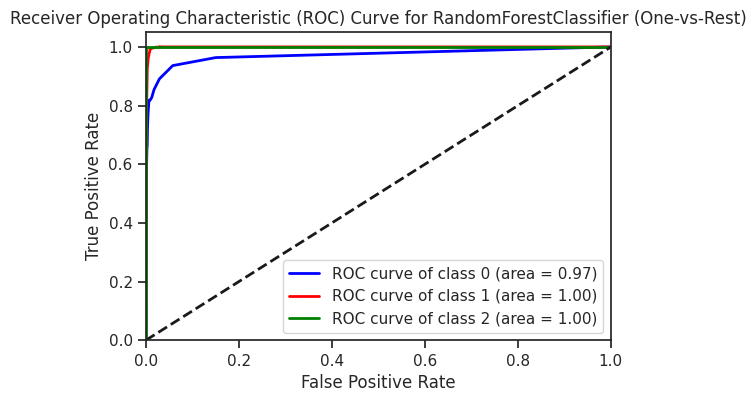

In [42]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the output
y_test_bin = label_binarize(y_test, classes=sorted(y_test.unique()))
n_classes = y_test_bin.shape[1]

# Get the predicted probabilities for each class for RandomForestClassifier
y_prob_rf = rf_classifier.predict_proba(X_test)

# Compute ROC curve and ROC area for each class for RandomForestClassifier
fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()

for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

# Plot the ROC curves for RandomForestClassifier
plt.figure(figsize=(6, 4))
colors = ['blue', 'red', 'green'] # Define colors for each class, extend if more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_rf[i], tpr_rf[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(sorted(y_test.unique())[i], roc_auc_rf[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for RandomForestClassifier (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

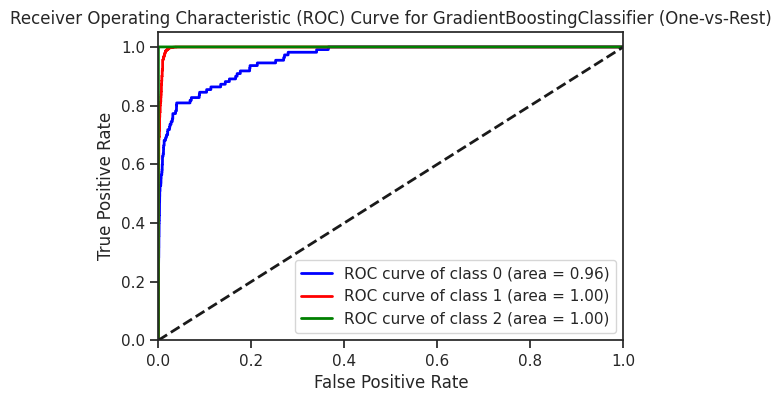

In [43]:
# Get the predicted probabilities for each class for GradientBoostingClassifier
y_prob_gb = gb_classifier.predict_proba(X_test)

# Compute ROC curve and ROC area for each class for GradientBoostingClassifier
fpr_gb = dict()
tpr_gb = dict()
roc_auc_gb = dict()

for i in range(n_classes):
    fpr_gb[i], tpr_gb[i], _ = roc_curve(y_test_bin[:, i], y_prob_gb[:, i])
    roc_auc_gb[i] = auc(fpr_gb[i], tpr_gb[i])

# Plot the ROC curves for GradientBoostingClassifier
plt.figure(figsize=(6, 4))
colors = ['blue', 'red', 'green'] # Define colors for each class, extend if more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_gb[i], tpr_gb[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(sorted(y_test.unique())[i], roc_auc_gb[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for GradientBoostingClassifier (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

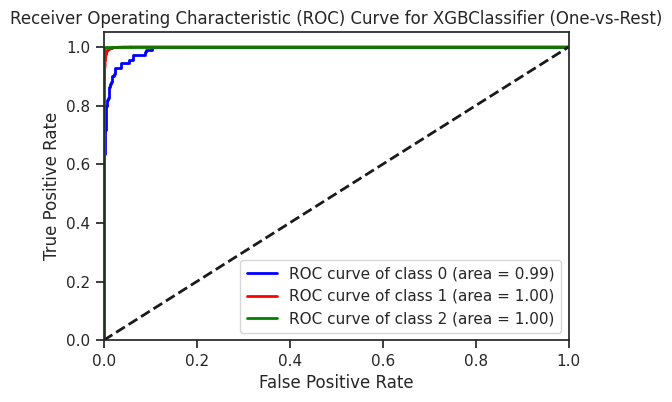

In [44]:
# Get the predicted probabilities for each class for XGBClassifier
y_prob_xgb = xgb_classifier.predict_proba(X_test)

# Compute ROC curve and ROC area for each class for XGBClassifier
fpr_xgb = dict()
tpr_xgb = dict()
roc_auc_xgb = dict()

for i in range(n_classes):
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])

# Plot the ROC curves for XGBClassifier
plt.figure(figsize=(6, 4))
colors = ['blue', 'red', 'green'] # Define colors for each class, extend if more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr_xgb[i], tpr_xgb[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(sorted(y_test.unique())[i], roc_auc_xgb[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for XGBClassifier (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

In [45]:
# Display the calculated AUC values for RandomForest
print("AUC values for RandomForestClassifier per class (One-vs-Rest):")
for i, label in enumerate(sorted(y_test.unique())):
    print(f"Class {label} (Encoded): {roc_auc_rf[i]:.4f}")

AUC values for RandomForestClassifier per class (One-vs-Rest):
Class 0 (Encoded): 0.9720
Class 1 (Encoded): 0.9985
Class 2 (Encoded): 1.0000


In [46]:
# Display the calculated AUC values for GradientBoostingClassifier
print("AUC values for GradientBoostingClassifier per class (One-vs-Rest):")
for i, label in enumerate(sorted(y_test.unique())):
    print(f"Class {label} (Encoded): {roc_auc_gb[i]:.4f}")

AUC values for GradientBoostingClassifier per class (One-vs-Rest):
Class 0 (Encoded): 0.9594
Class 1 (Encoded): 0.9976
Class 2 (Encoded): 1.0000


In [47]:
# Display the calculated AUC values for XGBClassifier
print("AUC values for XGBClassifier per class (One-vs-Rest):")
for i, label in enumerate(sorted(y_test.unique())):
    print(f"Class {label} (Encoded): {roc_auc_xgb[i]:.4f}")

AUC values for XGBClassifier per class (One-vs-Rest):
Class 0 (Encoded): 0.9925
Class 1 (Encoded): 0.9994
Class 2 (Encoded): 1.0000


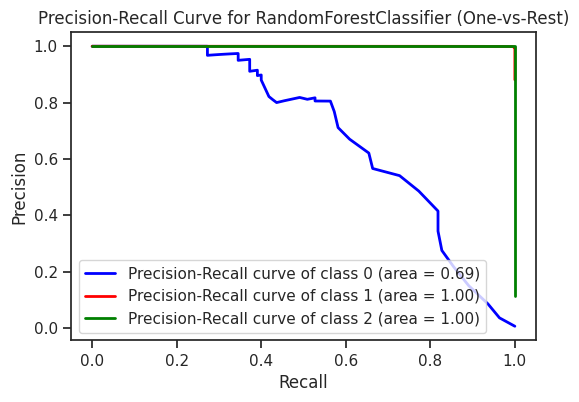

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute Precision-Recall curve and area for each class for RandomForestClassifier
precision = dict()
recall = dict()
average_precision = dict()

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_rf[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_prob_rf[:, i])

# Plot the Precision-Recall curves
plt.figure(figsize=(6, 4))
colors = ['blue', 'red', 'green'] # Define colors for each class, extend if more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='Precision-Recall curve of class {0} (area = {1:0.2f})'.format(sorted(y_test.unique())[i], average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for RandomForestClassifier (One-vs-Rest)')
plt.legend(loc="lower left")
plt.show()

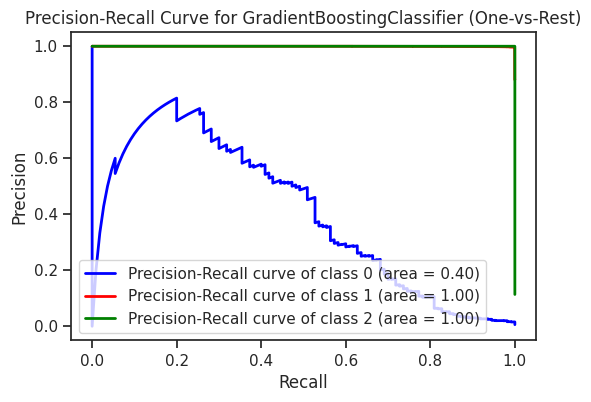

In [49]:
# Compute Precision-Recall curve and area for each class for GradientBoostingClassifier
precision_gb = dict()
recall_gb = dict()
average_precision_gb = dict()

for i in range(n_classes):
    precision_gb[i], recall_gb[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_gb[:, i])
    average_precision_gb[i] = average_precision_score(y_test_bin[:, i], y_prob_gb[:, i])

# Plot the Precision-Recall curves for GradientBoostingClassifier
plt.figure(figsize=(6, 4))
colors = ['blue', 'red', 'green'] # Define colors for each class, extend if more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(recall_gb[i], precision_gb[i], color=color, lw=2,
             label='Precision-Recall curve of class {0} (area = {1:0.2f})'.format(sorted(y_test.unique())[i], average_precision_gb[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for GradientBoostingClassifier (One-vs-Rest)')
plt.legend(loc="lower left")
plt.show()

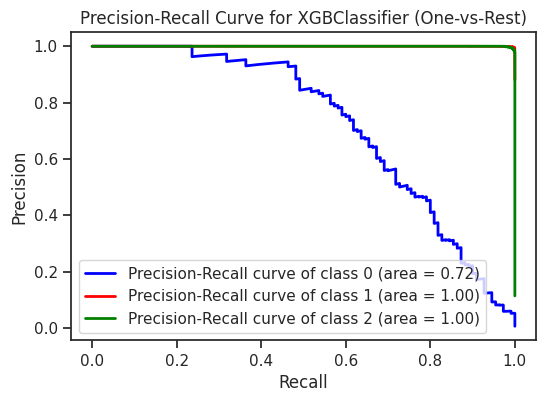

In [50]:
# Compute Precision-Recall curve and area for each class for XGBClassifier
precision_xgb = dict()
recall_xgb = dict()
average_precision_xgb = dict()

for i in range(n_classes):
    precision_xgb[i], recall_xgb[i], _ = precision_recall_curve(y_test_bin[:, i], y_prob_xgb[:, i])
    average_precision_xgb[i] = average_precision_score(y_test_bin[:, i], y_prob_xgb[:, i])

# Plot the Precision-Recall curves for XGBClassifier
plt.figure(figsize=(6, 4))
colors = ['blue', 'red', 'green'] # Define colors for each class, extend if more classes

for i, color in zip(range(n_classes), colors):
    plt.plot(recall_xgb[i], precision_xgb[i], color=color, lw=2,
             label='Precision-Recall curve of class {0} (area = {1:0.2f})'.format(sorted(y_test.unique())[i], average_precision_xgb[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for XGBClassifier (One-vs-Rest)')
plt.legend(loc="lower left")
plt.show()

#Modern Metrics

In [51]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

# Initialize the base classifier (your trained RandomForestClassifier)
base_classifier = rf_classifier

# Initialize CalibratedClassifierCV with the base classifier and method
calibrated_classifier = CalibratedClassifierCV(base_classifier, method='isotonic', cv='prefit')

# Fit the calibrated classifier on the training data (it uses the pre-fitted base classifier)
calibrated_classifier.fit(X_train, y_train)

# Get calibrated probabilities on the test set
calibrated_probs = calibrated_classifier.predict_proba(X_test)

# Evaluate the calibrated probabilities using a metric like Log Loss
logloss = log_loss(y_test, calibrated_probs)

print(f"Log Loss of the calibrated RandomForestClassifier: {logloss:.4f}")

# You can also make predictions with the calibrated model
calibrated_y_pred = calibrated_classifier.predict(X_test)

# And evaluate its accuracy
calibrated_accuracy = accuracy_score(y_test, calibrated_y_pred)
print(f"Accuracy of the calibrated RandomForestClassifier: {calibrated_accuracy:.4f}")

# Compare with the original accuracy
print(f"Original RandomForestClassifier Accuracy: {accuracy_rf:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Log Loss of the calibrated RandomForestClassifier: 0.1364
Accuracy of the calibrated RandomForestClassifier: 0.9962
Original RandomForestClassifier Accuracy: 0.9962


In [52]:
# Initialize the base classifier (your trained GradientBoostingClassifier)
base_classifier_gb = gb_classifier

# Initialize CalibratedClassifierCV with the base classifier and method
calibrated_classifier_gb = CalibratedClassifierCV(base_classifier_gb, method='isotonic', cv='prefit')

# Fit the calibrated classifier on the training data (it uses the pre-fitted base classifier)
calibrated_classifier_gb.fit(X_train, y_train)

# Get calibrated probabilities on the test set
calibrated_probs_gb = calibrated_classifier_gb.predict_proba(X_test)

# Evaluate the calibrated probabilities using a metric like Log Loss
logloss_gb = log_loss(y_test, calibrated_probs_gb)

print(f"Log Loss of the calibrated GradientBoostingClassifier: {logloss_gb:.4f}")

# You can also make predictions with the calibrated model
calibrated_y_pred_gb = calibrated_classifier_gb.predict(X_test)

# And evaluate its accuracy
calibrated_accuracy_gb = accuracy_score(y_test, calibrated_y_pred_gb)
print(f"Accuracy of the calibrated GradientBoostingClassifier: {calibrated_accuracy_gb:.4f}")

# Compare with the original accuracy
print(f"Original GradientBoostingClassifier Accuracy: {accuracy_gb:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Log Loss of the calibrated GradientBoostingClassifier: 0.0242
Accuracy of the calibrated GradientBoostingClassifier: 0.9952
Original GradientBoostingClassifier Accuracy: 0.9951


In [53]:
# Initialize the base classifier (your trained XGBClassifier)
base_classifier_xgb = xgb_classifier

# Initialize CalibratedClassifierCV with the base classifier and method
calibrated_classifier_xgb = CalibratedClassifierCV(base_classifier_xgb, method='isotonic', cv='prefit')

# Fit the calibrated classifier on the training data (it uses the pre-fitted base classifier)
calibrated_classifier_xgb.fit(X_train, y_train)

# Get calibrated probabilities on the test set
calibrated_probs_xgb = calibrated_classifier_xgb.predict_proba(X_test)

# Evaluate the calibrated probabilities using a metric like Log Loss
logloss_xgb = log_loss(y_test, calibrated_probs_xgb)

print(f"Log Loss of the calibrated XGBClassifier: {logloss_xgb:.4f}")

# You can also make predictions with the calibrated model
calibrated_y_pred_xgb = calibrated_classifier_xgb.predict(X_test)

# And evaluate its accuracy
calibrated_accuracy_xgb = accuracy_score(y_test, calibrated_y_pred_xgb)
print(f"Accuracy of the calibrated XGBClassifier: {calibrated_accuracy_xgb:.4f}")

# Compare with the original accuracy
print(f"Original XGBClassifier Accuracy: {accuracy_xgb:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Log Loss of the calibrated XGBClassifier: 0.1509
Accuracy of the calibrated XGBClassifier: 0.9951
Original XGBClassifier Accuracy: 0.9950


In [54]:
# Create a noisy copy of the test data
X_test_noisy = X_test.copy()

# Define the amount of noise to add (you can adjust this)
noise_level = 0.1 # Example: add noise with a standard deviation of 0.1

# Add random noise to the numerical columns
for col in X_test_noisy.select_dtypes(include=np.number).columns:
    noise = np.random.normal(0, noise_level, X_test_noisy[col].shape)
    X_test_noisy[col] = X_test_noisy[col] + noise

print("Shape of the noisy test data:", X_test_noisy.shape)

Shape of the noisy test data: (19291, 8)


In [55]:
from sklearn.metrics import accuracy_score

# Make predictions on the noisy test data with RandomForestClassifier
y_pred_rf_noisy = rf_classifier.predict(X_test_noisy)

# Evaluate the accuracy on the noisy data
accuracy_rf_noisy = accuracy_score(y_test, y_pred_rf_noisy)

print(f"RandomForestClassifier Accuracy on noisy data: {accuracy_rf_noisy:.4f}")
print(f"Original RandomForestClassifier Accuracy: {accuracy_rf:.4f}")

RandomForestClassifier Accuracy on noisy data: 0.9718
Original RandomForestClassifier Accuracy: 0.9962


In [56]:
from sklearn.metrics import accuracy_score

# Make predictions on the noisy test data with GradientBoostingClassifier
y_pred_gb_noisy = gb_classifier.predict(X_test_noisy)

# Evaluate the accuracy on the noisy data
accuracy_gb_noisy = accuracy_score(y_test, y_pred_gb_noisy)

print(f"GradientBoostingClassifier Accuracy on noisy data: {accuracy_gb_noisy:.4f}")
print(f"Original GradientBoostingClassifier Accuracy: {accuracy_gb:.4f}")

GradientBoostingClassifier Accuracy on noisy data: 0.9558
Original GradientBoostingClassifier Accuracy: 0.9951


In [57]:
from sklearn.metrics import accuracy_score

# Make predictions on the noisy test data with XGBClassifier
y_pred_xgb_noisy = xgb_classifier.predict(X_test_noisy)

# Evaluate the accuracy on the noisy data
accuracy_xgb_noisy = accuracy_score(y_test, y_pred_xgb_noisy)

print(f"XGBClassifier Accuracy on noisy data: {accuracy_xgb_noisy:.4f}")
print(f"Original XGBClassifier Accuracy: {accuracy_xgb:.4f}")

XGBClassifier Accuracy on noisy data: 0.9717
Original XGBClassifier Accuracy: 0.9950


In [58]:
import pandas as pd
from sklearn.metrics import classification_report

# Get the classification report as a dictionary
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)

# Convert the dictionary to a pandas DataFrame
performance_df_rf = pd.DataFrame(report_dict).transpose()

print("Performance Metrics for RandomForestClassifier:")
display(performance_df_rf)

Performance Metrics for RandomForestClassifier:


,precision,recall,f1-score,support
0,0.950000,0.345455,0.506667,110.000000
1,0.995780,0.999882,0.997827,16991.000000
2,1.000000,1.000000,1.000000,2190.000000
accuracy,0.996164,0.996164,0.996164,0.996164
macro avg,0.981927,0.781779,0.834831,19291.000000
weighted avg,0.995998,0.996164,0.995273,19291.000000


In [59]:
import pandas as pd
from sklearn.metrics import classification_report

# Get the classification report as a dictionary for GradientBoostingClassifier
report_dict_gb = classification_report(y_test, y_pred_gb, output_dict=True)

# Convert the dictionary to a pandas DataFrame
performance_df_gb = pd.DataFrame(report_dict_gb).transpose()

print("Performance Metrics for GradientBoostingClassifier:")
display(performance_df_gb)

Performance Metrics for GradientBoostingClassifier:


,precision,recall,f1-score,support
0,0.636364,0.318182,0.424242,110.000000
1,0.995600,0.998823,0.997209,16991.000000
2,1.000000,1.000000,1.000000,2190.000000
accuracy,0.995075,0.995075,0.995075,0.995075
macro avg,0.877321,0.772335,0.807150,19291.000000
weighted avg,0.994051,0.995075,0.994259,19291.000000


In [60]:
import pandas as pd
from sklearn.metrics import classification_report

# Get the classification report as a dictionary for XGBClassifier
report_dict_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

# Convert the dictionary to a pandas DataFrame
performance_df_xgb = pd.DataFrame(report_dict_xgb).transpose()

print("Performance Metrics for XGBClassifier:")
display(performance_df_xgb)

Performance Metrics for XGBClassifier:


,precision,recall,f1-score,support
0,0.940000,0.427273,0.587500,110.000000
1,0.995367,0.998999,0.997180,16991.000000
2,0.993601,0.992694,0.993148,2190.000000
accuracy,0.995024,0.995024,0.995024,0.995024
macro avg,0.976323,0.806322,0.859276,19291.000000
weighted avg,0.994851,0.995024,0.994386,19291.000000
